In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from pathlib import Path

def find_repo_root(start: Path = Path.cwd()) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / ".git").exists():
            return parent
    return start  

repo_root = find_repo_root()
os.chdir(repo_root)

In [2]:
from src.simulation.factories.simulator_factory import SimulatorFactory
from src.simulation.factories.pipeline_factory import PipelineFactory

simulator = SimulatorFactory.get_simulator('tt')
pipeline_planck_binning = PipelineFactory.get_pipeline('planck_binning')
pipeline_planck_processing = PipelineFactory.get_pipeline('planck_processing')

params_dict = {
    'ombh2': 0.02212,
    'omch2': 0.1206,
    'theta_MC_100': 1.04077,
    'ln_10_10_As': 3.04,
    'ns': 0.9626
}

params = torch.tensor(list(params_dict.values()))

/home/julian/miniconda3/envs/cobaya_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
simulator = SimulatorFactory.get_simulator('tt')

simulation = simulator.simulate(params)
simulation_batch = []
for _ in range(20):
    simulation_batch.append(simulation)
simulation_batch = torch.stack(simulation_batch)
print(simulation_batch.shape)

torch.Size([20, 2551])


In [4]:
planck_binning_data = pipeline_planck_binning.run(simulation)
print(planck_binning_data.shape)

torch.Size([74])


In [5]:
planck_processing_data = pipeline_planck_processing.run_batch(simulation_batch)
print(planck_processing_data.shape)

100%|██████████| 20/20 [00:00<00:00, 618.78it/s]

torch.Size([20, 74])


In [6]:
from src.data.planck import PlanckDataLoader

data = PlanckDataLoader()
cov_matrix, lmin, lmax, ell_low, dell_low, err_low, ell_high, dell_high, err_high = data.load_planck_data()

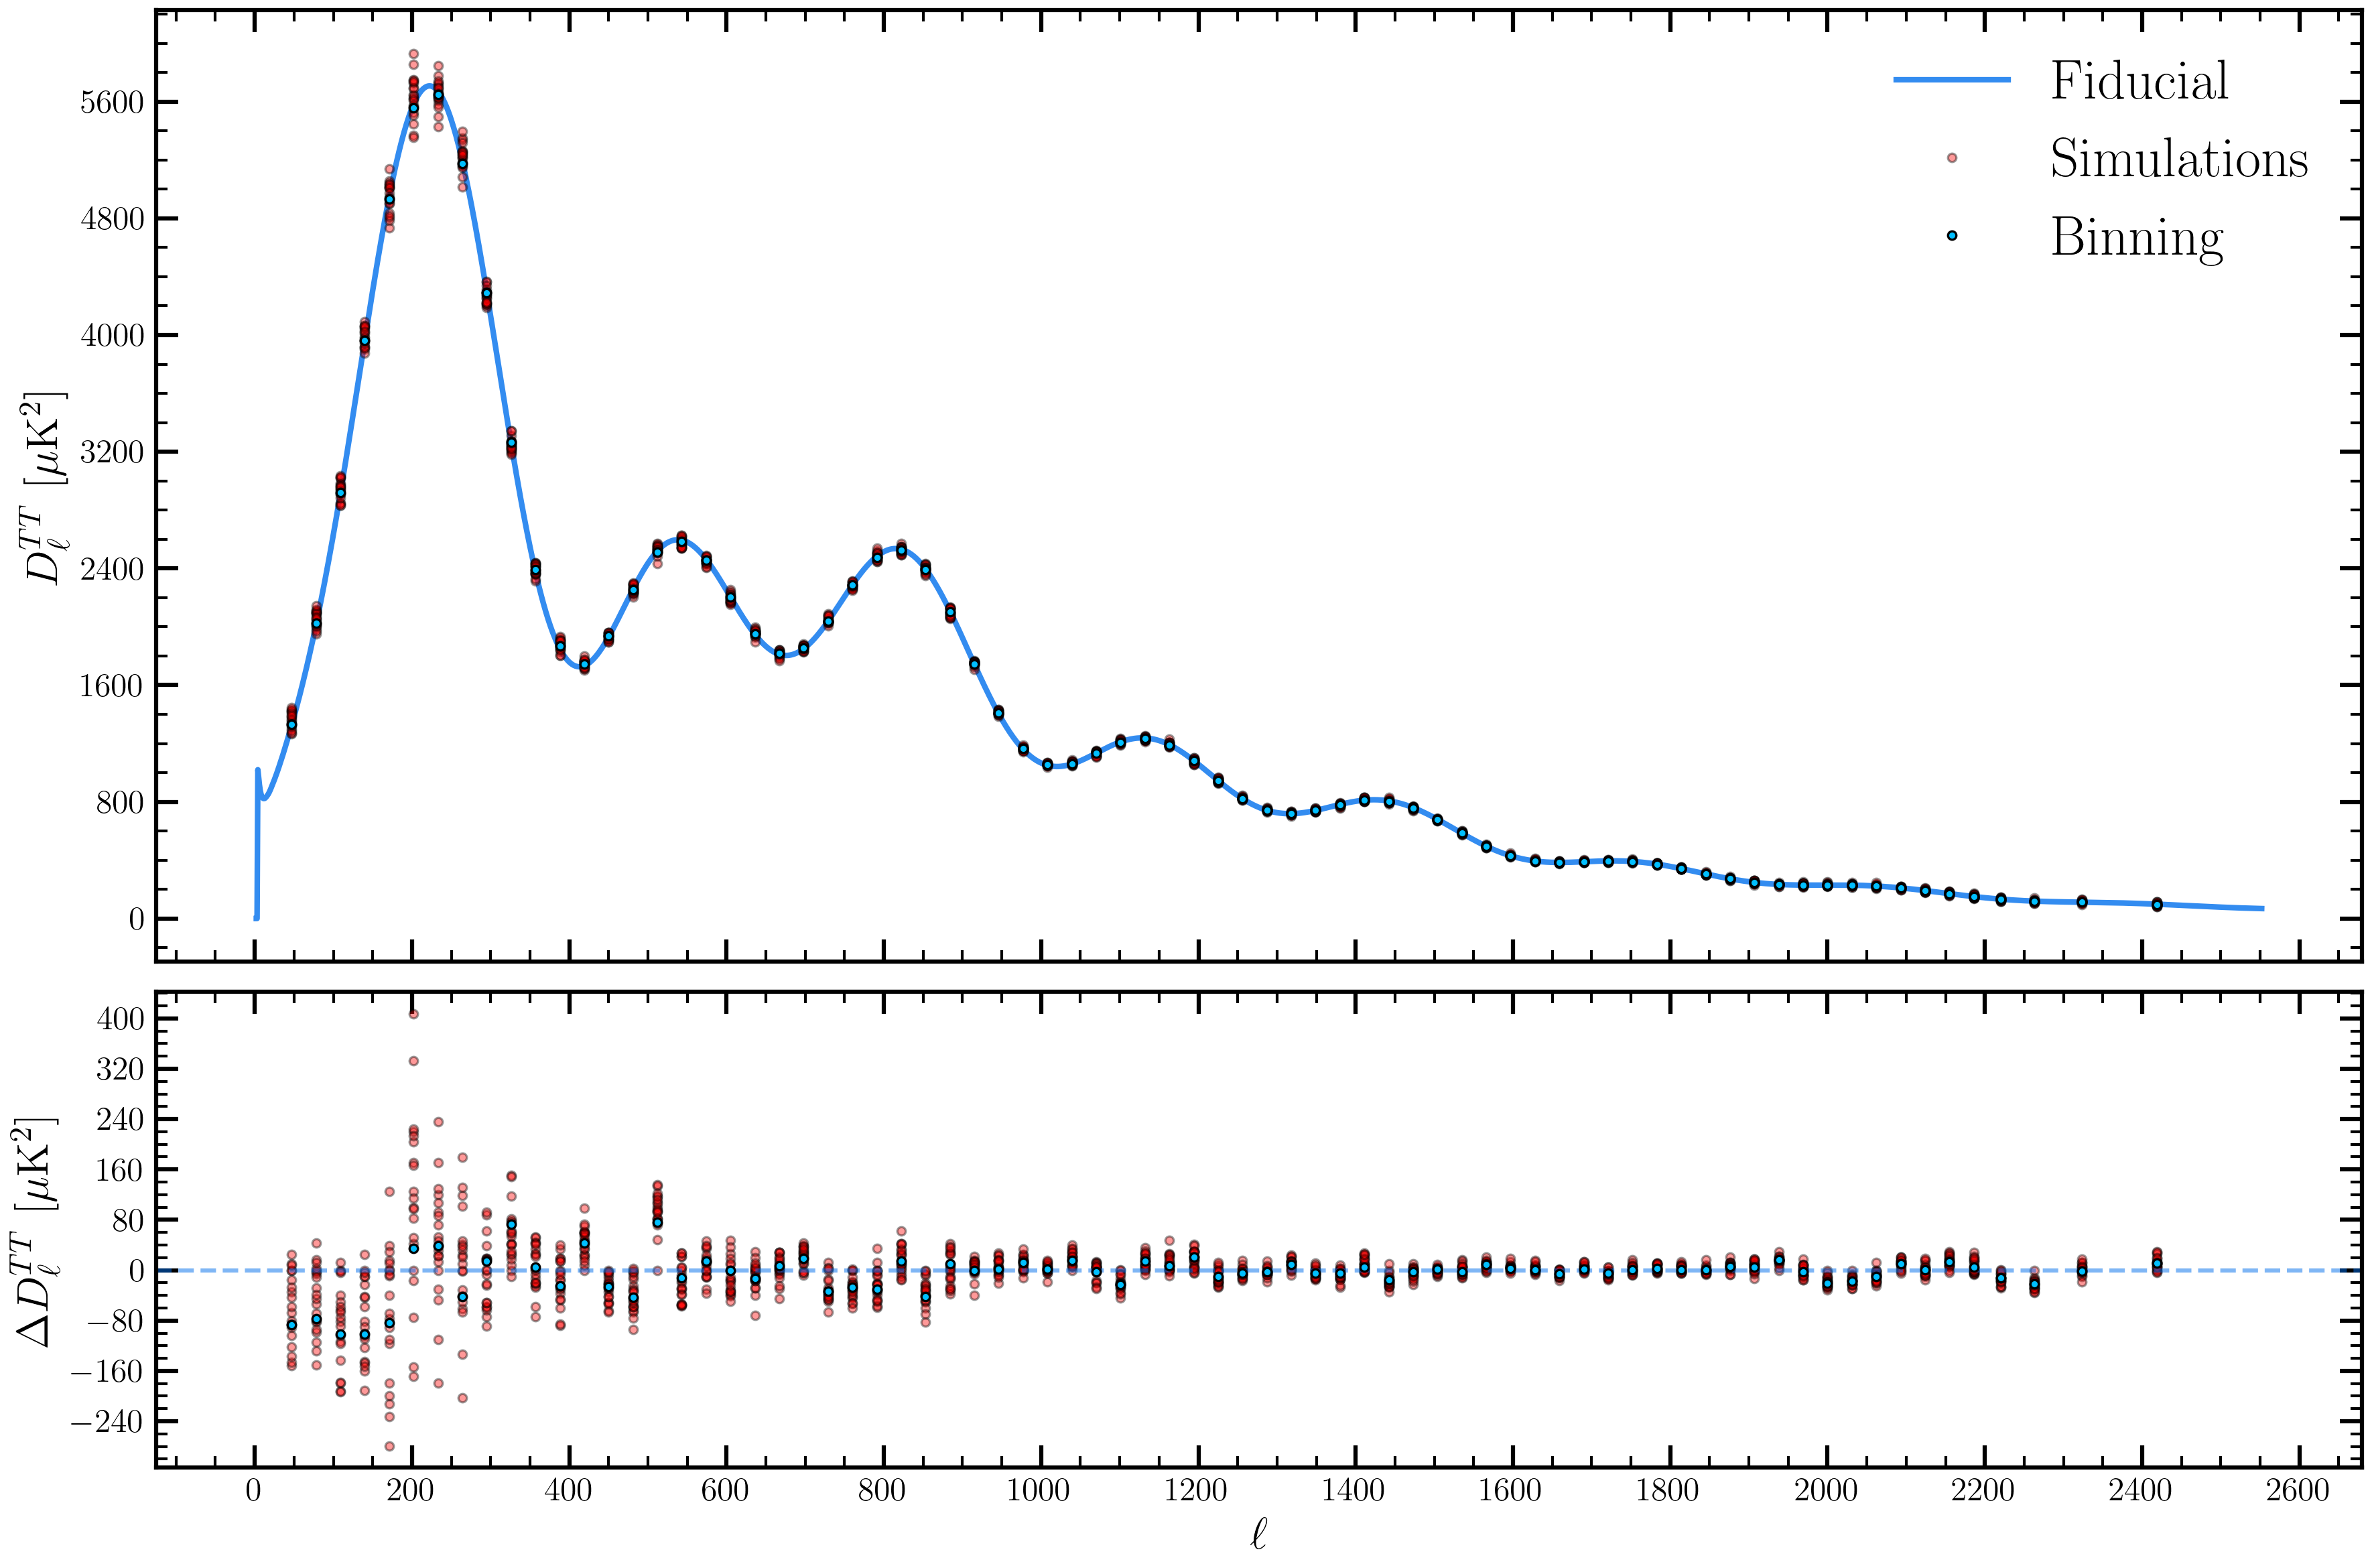

In [7]:
plt.style.use(['science', 'bright'])
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(np.arange(2, 2553), simulation_batch[0].numpy(), linewidth=2.0, alpha=0.8, color='#006FED', label='Fiducial')

for i in range(planck_processing_data.shape[0]):
    ax1.plot(ell_high, planck_processing_data[i].numpy(), 
            marker='o', linestyle='', markersize=3, alpha=0.4, color='red',
            markeredgecolor='black', markeredgewidth=0.8, label='Simulations' if i == 0 else None)
    
ax1.plot(ell_high, planck_binning_data.numpy(), marker='o', linestyle='', markersize=3, alpha=1, color='deepskyblue',
            markeredgecolor='black', markeredgewidth=0.8, label='Binning')

ax1.set_ylabel("$D_\\ell^{TT}$ [$\\mu$K$^2$]", fontsize=16)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', labelsize=12, width=1.5)

for i in range(planck_processing_data.shape[0]):
    residuals = planck_processing_data[i] - planck_processing_data[0]
    ax2.plot(ell_high, residuals,
            marker='o', linestyle='', markersize=3, alpha=0.4, color='red',
            markeredgecolor='black', markeredgewidth=0.8)

residuals_binning = planck_binning_data - planck_processing_data[0]

ax2.axhline(y=0, color='#006FED', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.plot(ell_high, residuals_binning.numpy(), marker='o', linestyle='', markersize=3, alpha=1, color='deepskyblue',
            markeredgecolor='black', markeredgewidth=0.8)

ax2.set_xlabel("$\\ell$", fontsize=16)
ax2.set_ylabel("$\Delta D_\\ell^{TT}$ [$\\mu$K$^2$]", fontsize=16)
ax2.tick_params(axis='both', labelsize=12, width=1.5)

from matplotlib.ticker import MaxNLocator
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15))
ax2.xaxis.set_major_locator(MaxNLocator(nbins=15))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=10))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=10))

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
from src.core.storage import storage
# storage.save_figure(fig, "processed_simulation_comparison.pdf")
plt.show()

In [8]:
theta_ombh2, x_ombh2 = storage.load_simulations("tt_ombh2_ombh2_5sigma_planck_binning_100_1.pt")
theta_omch2, x_omch2 = storage.load_simulations("tt_omch2_omch2_5sigma_planck_binning_100_1.pt")
theta_theta_MC_100, x_theta_MC_100 = storage.load_simulations("tt_theta_MC_100_theta_MC_100_5sigma_planck_binning_100_1.pt")
theta_ln_10_10_As, x_ln_10_10_As = storage.load_simulations("tt_ln_10_10_As_ln_10_10_As_5sigma_planck_binning_100_1.pt")
theta_ns, x_ns = storage.load_simulations("tt_ns_ns_5sigma_planck_binning_100_1.pt")

In [9]:
from src.simulation.api import simulate_observation

theta_true = torch.tensor([
    0.02212,    # ombh2
    0.1206,     # omch2
    1.04077,    # theta_MC_100
    3.04,       # ln_10_10_As
    0.9626      # ns
])

x_obs = simulate_observation(
    theta_true=theta_true,
    observation_type="binned_planck_tt",
    seed=1
)

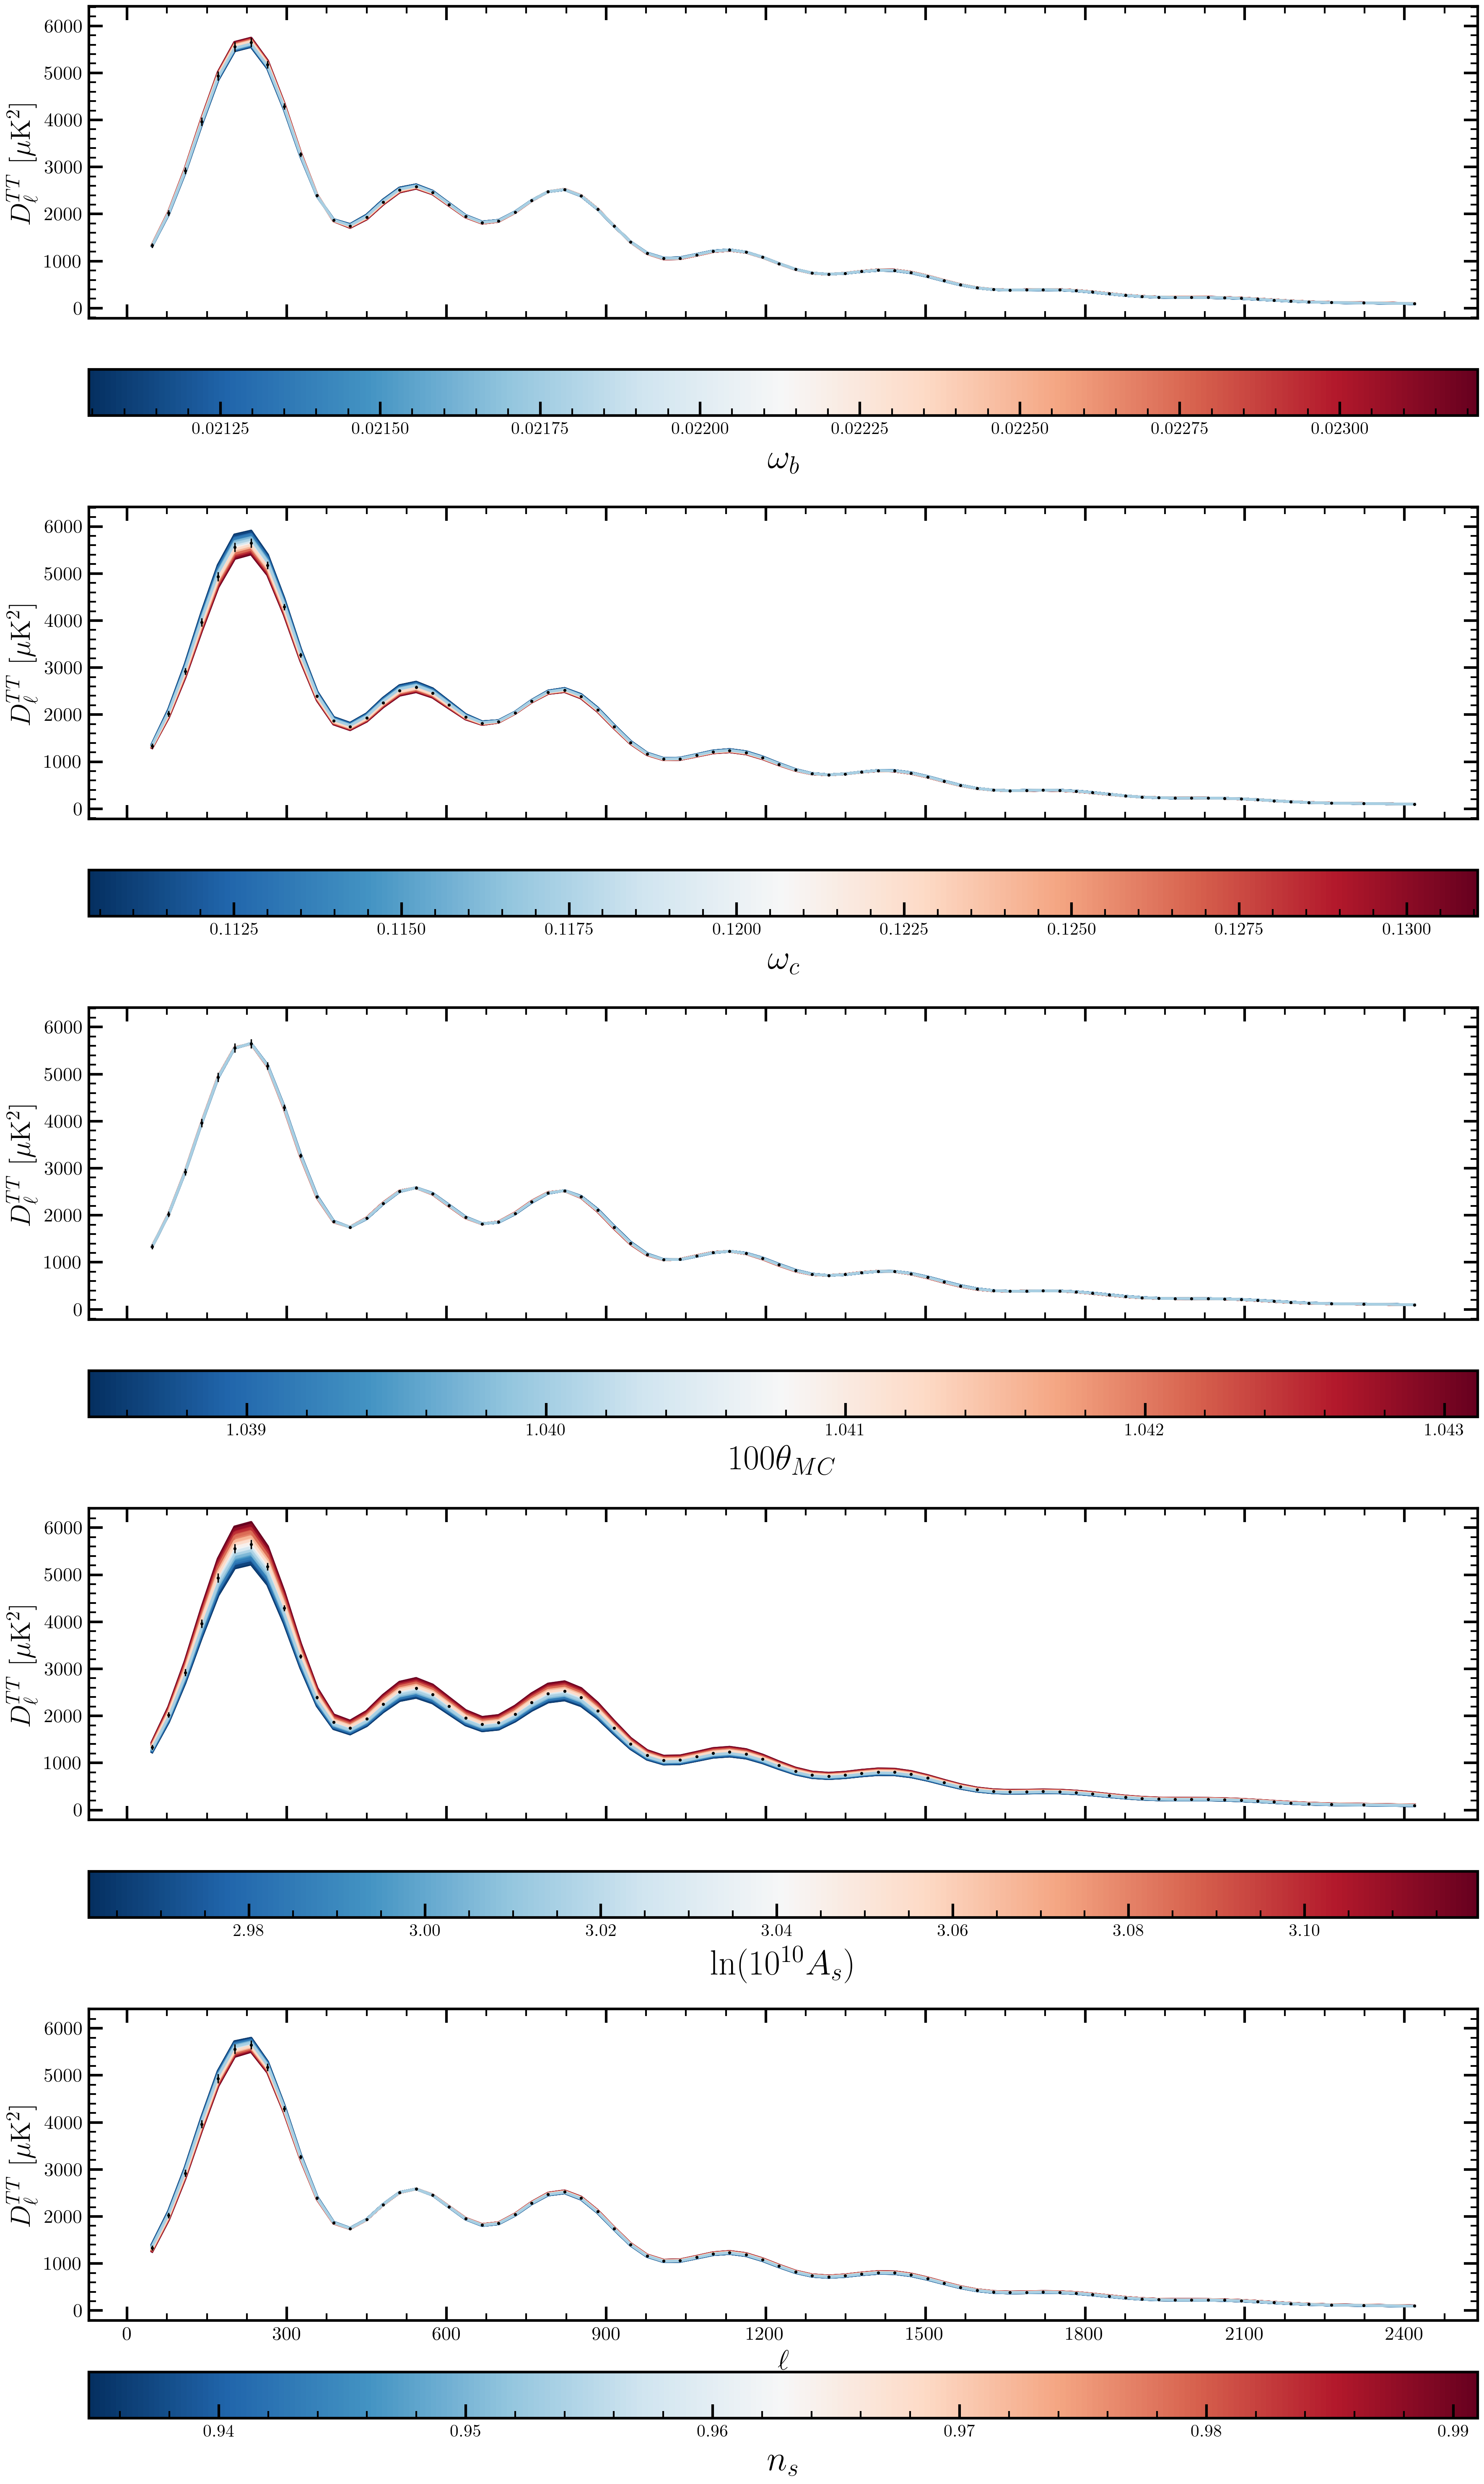

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True, sharey=True)

# Parameter names and data
param_names = ['$\omega_b$', '$\omega_c$', '$100\\theta_{MC}$', '$\ln(10^{10} A_s)$', '$n_s$']
param_data = [x_ombh2, x_omch2, x_theta_MC_100, x_ln_10_10_As, x_ns]
param_values = [theta_ombh2, theta_omch2, theta_theta_MC_100, theta_ln_10_10_As, theta_ns]

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Calculate 1sigma from covariance matrix diagonal
sigma = np.sqrt(np.diag(cov_matrix.numpy()))

for idx, (ax, name, data, theta_vals) in enumerate(zip(axes, param_names, param_data, param_values)):
    norm = Normalize(vmin=theta_vals.min().item(), vmax=theta_vals.max().item())
    cmap = plt.cm.RdBu_r  
    
    # Use ell_high as x-axis
    x_vals = ell_high.numpy()
    
    # Fill between consecutive curves to create gradient
    for i in range(data.shape[0] - 1):
        color = cmap(norm(theta_vals[i].item()))
        y1 = data[i].numpy()
        y2 = data[i+1].numpy()
        ax.fill_between(x_vals, y1, y2, color=color, alpha=0.6)
    
    # Plot the lines on top
    for i in range(data.shape[0]):
        color = cmap(norm(theta_vals[i].item()))
        ax.plot(x_vals, data[i].numpy(), linewidth=1.5, alpha=0.9, color=color)
    
    # Plot x_obs in black with vertical error bars (no caps)
    ax.errorbar(x_vals, x_obs.numpy(), yerr=sigma, fmt='.', markersize=1.5, 
                linewidth=1, color='black', ecolor='black', elinewidth=0.8, 
                capsize=0, label='Observation', zorder=10)
    
    ax.set_ylabel("$D_\\ell^{TT}$ [$\\mu$K$^2$]", fontsize=16)
    ax.tick_params(axis='both', labelsize=11, width=1.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(theta_vals.numpy())
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.12, aspect=30)
    cbar.set_label(name, fontsize=20)
    cbar.ax.tick_params(labelsize=10)

axes[-1].set_xlabel("$\\ell$", fontsize=16)

from matplotlib.ticker import MaxNLocator
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.tight_layout()
# storage.save_figure(fig, "parameter_variation_with_observation.pdf")
plt.show()